In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pyomo.environ as pyo
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

from pull_prices import merged_df_clean, merged_df_spike
from params import nodes, mcp, mdp, e, fee

# Create output folder
BASE_DIR = os.getcwd()
PLOT_DIR = os.path.join(BASE_DIR, "results", "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

print("Plots will be saved in:", PLOT_DIR)

[LMP] Loading from cache: cache_lmp_Jan 1, 2023_Dec 31, 2025_0c3247.pkl
[AS] Loading from cache: cache_as_Jan 1, 2023_Dec 31, 2025.pkl
[MERGE] LMP range:      2023-01-12 08:00:00 → 2025-12-31 07:00:00
[MERGE] AS range:       2023-01-01 08:00:00 → 2025-12-31 07:00:00
[MERGE] Final shape: (77760, 9)
Plots will be saved in: d:\battery-storage-optimization-energy-ancillary\results\plots


In [2]:
# [FIX D]: Removed unused Transformer class. Renamed function for clarity.
def compute_ewma_baseline(df):
    if df is None:
        raise ValueError("Received None dataframe")

    df = df.copy()

    if "SP15" not in df.columns:
        raise KeyError("SP15 column missing")

    # EWMA-based expected behavior
    df["expected_price"] = df["SP15"].ewm(span=24, adjust=False).mean()

    return df

In [3]:
def prepare_timeseries(df):

    # average price across nodes (simple fix)
    df_ts = df.groupby("datetime").agg({
        "SP15": "mean",
        "NonSpin": "mean",
        "RegDown": "mean",
        "RegUp": "mean",
        "Spin": "mean"
    }).reset_index()

    df_ts = df_ts.sort_values("datetime").reset_index(drop=True)

    return df_ts

In [4]:
# =========================
# 🔹 GRAPH (LEARNED)
# =========================
def build_graph(df):

    pivot = df.pivot(index="datetime", columns="node", values="SP15")
    pivot = pivot.ffill()

    A = pivot.corr().values
    np.fill_diagonal(A, 0)

    D = np.diag(A.sum(axis=1))
    L = D - A

    return L

In [5]:
def compute_anomaly(df):
    df = df.copy()

    if "expected_price" not in df.columns:
        raise KeyError("expected_price missing — run train_vae first")

    X = df[["SP15"]].values

    iso = IsolationForest(contamination=0.05)
    lof = LocalOutlierFactor()

    df["iso"] = (iso.fit_predict(X) == -1).astype(int)
    df["lof"] = (lof.fit_predict(X) == -1).astype(int)

    df["res"] = abs(df["SP15"] - df["expected_price"])

    scaler = MinMaxScaler()
    df[["res"]] = scaler.fit_transform(df[["res"]])

    df["anomaly"] = df["res"] + df["iso"] + df["lof"]
    df["anomaly"] = MinMaxScaler().fit_transform(df[["anomaly"]])

    return df

In [6]:
def classify_anomaly(df, window=6, persist_threshold=2):
    df = df.copy()

    # rate of change
    df["roc"] = df["SP15"].diff().abs()
    df["roc"] = df["roc"] / (df["SP15"].shift(1).abs() + 1e-8)
    df["roc"] = df["roc"].fillna(0)  # row 0 has no prior — treat as no change

    # persistence — how many surrounding hours are also anomalous
    df["anom_binary"]  = (df["anomaly"] > 0.5).astype(int)
    df["persistence"]  = (
        df["anom_binary"]
        .rolling(window, center=True, min_periods=1)
        .sum()
    )

    # local z-score
    df["local_mean"] = df["SP15"].rolling(window, center=True, min_periods=1).mean()
    df["local_std"]  = df["SP15"].rolling(window, center=True, min_periods=1).std().fillna(1)
    df["z_score"]    = (df["SP15"] - df["local_mean"]) / df["local_std"]

    # mean reversion — does price come back down after the spike?
    df["future_mean"] = df["SP15"].shift(-window).rolling(window, min_periods=1).mean()
    df["reverts"]     = (df["future_mean"] < df["SP15"]).astype(int)

    # genuine if: persists + reverts + not an instant jump
    df["is_genuine"] = (
        (df["persistence"] >= persist_threshold) &
        (df["reverts"] == 1) &
        (df["roc"] < 0.5)
    ).astype(int)

    # boost genuine spikes, suppress noise
    df["anomaly_adjusted"] = df["anomaly"] * np.where(df["is_genuine"], 1.5, 0.3)
    df["anomaly_adjusted"] = df["anomaly_adjusted"].clip(0, 1)

    return df

In [7]:
from params import mcp, mdp, e, fee

try:
    from params import degradation_cost
except ImportError:
    degradation_cost = 2.5  # fallback if not defined in params.py

def optimize(df, L, mode="baseline", anomaly_sensitivity=0.3):
    df = df.copy().reset_index(drop=True)
    df["anomaly"]    = df["anomaly"].fillna(0).clip(0, 1)
    df["is_genuine"] = df["is_genuine"].fillna(0)

    anomaly_sensitivity = 0.3

    model = pyo.ConcreteModel()
    T = len(df)

    model.t = pyo.RangeSet(0, T - 1)

    model.price    = pyo.Param(model.t, initialize=lambda m, t: float(df["SP15"].iloc[t]))
    model.anom     = pyo.Param(model.t, initialize=lambda m, t: float(df["anomaly"].iloc[t]))
    model.genuine  = pyo.Param(model.t, initialize=lambda m, t: float(df["is_genuine"].iloc[t]))

    # [FIX A]: Removed model.n to represent a single physical battery 
    model.buy  = pyo.Var(model.t, bounds=(0, mcp))
    model.sell = pyo.Var(model.t, bounds=(0, 1.2 * mdp))
    model.soc  = pyo.Var(model.t, bounds=(0, mcp))

    # --- SOC BALANCE ---
    def soc_rule(m, t):
        if t == 0:
            return m.soc[t] == mcp
        return m.soc[t] == m.soc[t-1] + m.buy[t] * e - m.sell[t] / e

    model.soc_c = pyo.Constraint(model.t, rule=soc_rule)

    # --- PHYSICAL FEASIBILITY ---
    def sell_energy_rule(m, t):
        if t == 0:
            return m.sell[t] == 0
        return m.sell[t] / e <= m.soc[t - 1]

    model.sell_energy_c = pyo.Constraint(model.t, rule=sell_energy_rule)

    def buy_headroom_rule(m, t):
        if t == 0:
            return pyo.Constraint.Skip
        return m.buy[t] * e <= mcp - m.soc[t - 1]

    model.buy_headroom_c = pyo.Constraint(model.t, rule=buy_headroom_rule)

    # --- SELL CAP (mode-dependent) ---
    def sell_limit_rule(m, t):
        if mode == "baseline":
            return m.sell[t] <= mdp
        elif mode == "penalised":
            return m.sell[t] <= mdp * (1 - anomaly_sensitivity * m.anom[t])
        elif mode == "opportunistic":
            return m.sell[t] <= mdp * (
                1
                + anomaly_sensitivity * m.anom[t] * m.genuine[t]
                - anomaly_sensitivity * m.anom[t] * (1 - m.genuine[t])
            )

    model.sell_limit = pyo.Constraint(model.t, rule=sell_limit_rule)

    # --- OBJECTIVE (mode-dependent) ---
    def obj(m):
        # [IMPROVEMENT]: Added degradation_cost to all scenarios to penalize cycling
        if mode == "baseline":
            return sum(
                m.sell[t] * m.price[t]
                - m.buy[t] * m.price[t]
                - (fee + degradation_cost) * (m.sell[t] + m.buy[t])
                for t in m.t 
            )

        elif mode == "penalised":
            return sum(
                m.sell[t] * m.price[t] * (1 - anomaly_sensitivity * m.anom[t])
                - m.buy[t] * m.price[t] * (1 + anomaly_sensitivity * m.anom[t])
                - (fee + degradation_cost) * (m.sell[t] + m.buy[t])
                for t in m.t 
            )

        elif mode == "opportunistic":
            return sum(
                m.sell[t] * m.price[t] * (
                    1 + anomaly_sensitivity * m.anom[t] * m.genuine[t]       
                    - anomaly_sensitivity * m.anom[t] * (1 - m.genuine[t])   
                )
                - m.buy[t] * m.price[t] * (
                    1 - anomaly_sensitivity * m.anom[t] * m.genuine[t]       
                    + anomaly_sensitivity * m.anom[t] * (1 - m.genuine[t])   
                )
                - (fee + degradation_cost) * (m.sell[t] + m.buy[t])
                for t in m.t 
            )

    model.obj = pyo.Objective(rule=obj, sense=pyo.maximize)

    solver_result = pyo.SolverFactory("highs").solve(model)

    soc    = [pyo.value(model.soc[t]) for t in model.t]
    profit = pyo.value(model.obj) or 0.0

    return profit, soc

In [20]:
def calculate_performance_metrics(profit, soc_list, capacity_mwh=10.0):
    """
    Calculates battery degradation metrics based on the State of Charge (SOC) profile.
    """
    total_discharge_mwh = 0.0

    # Iterate through the SOC list to find all discharging events
    for t in range(1, len(soc_list)):
        # If SOC drops, it means we discharged
        if soc_list[t] < soc_list[t - 1]:
            total_discharge_mwh += (soc_list[t - 1] - soc_list[t])

    # EFC = Total energy discharged / Total capacity
    efc = total_discharge_mwh / capacity_mwh

    # Avoid division by zero if the battery did nothing
    profit_per_cycle = profit / efc if efc > 0 else 0.0

    return efc, profit_per_cycle


# --- Use the variables that already exist in this notebook ---
profit_value = globals().get("p_opp", globals().get("a_opp", globals().get("c_opp")))
soc_value = globals().get("soc_opp", globals().get("a_soc_opp", globals().get("c_soc_opp")))

if profit_value is None or soc_value is None:
    raise NameError("No opportunistic profit/SOC variables found. Run optimize() first.")

efc_opp, ppc_opp = calculate_performance_metrics(profit_value, soc_value, capacity_mwh=10.0)
print(f"Opportunistic Strategy:")
print(f"  Total Profit: ${profit_value:,.2f}")
print(f"  Equivalent Full Cycles (EFC): {efc_opp:.1f} cycles")
print(f"  Profit per Cycle: ${ppc_opp:,.2f}/cycle")

Opportunistic Strategy:
  Total Profit: $370,209.09
  Equivalent Full Cycles (EFC): 1055.4 cycles
  Profit per Cycle: $350.78/cycle


In [21]:
# =========================
# 🔹 PLOTTING (SAVE ONLY)
# =========================

def plot_price_comparison(df, name):

    plt.figure(figsize=(12,5))
    plt.plot(df["SP15"].values, label="Actual Price")
    plt.plot(df["expected_price"].values, label="Expected Price")

    plt.title("Price vs Expected Price")
    plt.legend()
    plt.grid()

    filepath = os.path.join(PLOT_DIR, f"{name}_price.png")
    plt.savefig(filepath)
    plt.close()


def plot_soc_comparison(base_soc, anom_soc, name):

    plt.figure(figsize=(12,5))
    plt.plot(base_soc, label="Baseline SOC")
    plt.plot(anom_soc, label="Anomaly SOC")

    plt.title("SOC Comparison")
    plt.legend()
    plt.grid()

    filepath = os.path.join(PLOT_DIR, f"{name}_soc.png")
    plt.savefig(filepath)
    plt.close()


def plot_volatility(df, name):

    df = df.copy()
    df["volatility"] = df["SP15"].rolling(24).std()

    plt.figure(figsize=(12,4))
    plt.plot(df["volatility"], color="purple")

    plt.title("Volatility")
    plt.grid()

    filepath = os.path.join(PLOT_DIR, f"{name}_volatility.png")
    plt.savefig(filepath)
    plt.close()


def plot_profit(c_base, c_pen, c_opp, a_base, a_pen, a_opp):
    x     = np.arange(3)
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width, [c_base, c_pen, c_opp], width, label="Clean",  color="steelblue")
    ax.bar(x,         [a_base, a_pen, a_opp], width, label="Attack", color="crimson")

    ax.set_xticks(x)
    ax.set_xticklabels(["Baseline", "Penalised", "Opportunistic"])
    ax.set_title("Profit Comparison Across Strategies and Scenarios")
    ax.set_ylabel("Profit ($)")
    ax.legend()
    ax.grid(axis="y")

    filepath = os.path.join(PLOT_DIR, "profit_comparison.png")
    plt.savefig(filepath)
    plt.close()

In [22]:
class VAE(nn.Module):
    # [FIX B]: Changed input_dim to 24 to process full days
    def __init__(self, input_dim=24, latent_dim=8):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, 32)
        self.fc_mu = nn.Linear(32, latent_dim)
        self.fc_logvar = nn.Linear(32, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, 32)
        self.fc3 = nn.Linear(32, input_dim)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return self.fc3(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

In [23]:
def train_vae(df):
    df = df.copy()

    data = df["SP15"].values.reshape(-1, 1)
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    # [FIX B]: Reshape into 24-hour sequences (assumes data is multiple of 24)
    # If the length isn't perfectly divisible by 24, pad or trim it in production.
    seq_len = 24
    num_days = len(data_scaled) // seq_len
    data_seq = data_scaled[:num_days * seq_len].reshape(-1, seq_len)

    x = torch.tensor(data_seq, dtype=torch.float32)

    model = VAE(input_dim=seq_len)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    def loss_fn(recon, x, mu, logvar):
        recon_loss = nn.MSELoss()(recon, x)
        kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        return recon_loss + kl_loss

    # Training
    dataset = torch.utils.data.TensorDataset(x)
    loader  = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True)

    model.train()
    for epoch in range(50):
        epoch_loss = 0.0
        for (batch,) in loader:
            optimizer.zero_grad()
            recon, mu, logvar = model(batch)
            loss = loss_fn(recon, batch, mu, logvar)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

    # Reconstruction
    model.eval()
    with torch.no_grad():
        recon, _, _ = model(x)
    
    # Flatten back to 1D timeseries
    recon_np = recon.numpy().reshape(-1, 1)
    
    # Pad the end if we trimmed it earlier
    if len(recon_np) < len(df):
        pad = np.zeros((len(df) - len(recon_np), 1))
        recon_np = np.vstack([recon_np, pad])

    df["expected_price"] = scaler.inverse_transform(recon_np)

    return df, model, scaler

In [24]:
def compute_gradcam(model, x_tensor, target_idx=None):
    """
    Compute Grad-CAM scores for VAE reconstruction.
    Returns a numpy array of shape (T,) — one score per timestep.
    Higher score = this timestep had more influence on reconstruction error.
    """
    model.eval()

    # We'll compute gradient of reconstruction loss w.r.t. input
    x_input = x_tensor.clone().requires_grad_(True)

    recon, mu, logvar = model(x_input)

    # Reconstruction loss per timestep (not reduced)
    recon_loss_per_t = (recon - x_input).pow(2).squeeze()  # shape (T,)

    if target_idx is not None:
        # Gradient w.r.t. a specific timestep's loss
        scalar = recon_loss_per_t[target_idx]
    else:
        # Gradient w.r.t. total reconstruction loss
        scalar = recon_loss_per_t.sum()

    scalar.backward()

    # Gradient of loss w.r.t. input — shape (T, 1)
    gradients = x_input.grad.abs().squeeze().detach().numpy()  # shape (T,)

    # Normalise to [0, 1]
    gradients = (gradients - gradients.min()) / (gradients.max() - gradients.min() + 1e-8)

    return gradients


def plot_gradcam(df, gradcam_scores, name):
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    axes[0].plot(df["SP15"].values, label="SP15 Price", color="steelblue")
    axes[0].plot(df["expected_price"].values, label="Expected Price", color="orange", linestyle="--")
    axes[0].set_title("Price vs Expected")
    axes[0].legend()
    axes[0].grid()

    axes[1].bar(range(len(gradcam_scores)), gradcam_scores, color="crimson", alpha=0.7)
    axes[1].set_title("Grad-CAM: VAE Attention per Timestep")
    axes[1].set_xlabel("Timestep (hours)")
    axes[1].set_ylabel("Influence Score")
    axes[1].grid(axis="y")

    plt.tight_layout()
    filepath = os.path.join(PLOT_DIR, f"{name}_gradcam.png")
    plt.savefig(filepath)
    plt.close()
    print(f"[GradCAM] Saved: {filepath}")

In [25]:
def run(df):
    df_graph = df.copy()
    df_ts = prepare_timeseries(df)

    df_ts, vae_model, vae_scaler = train_vae(df_ts)
    df_ts = compute_anomaly(df_ts)
    df_ts = classify_anomaly(df_ts)
    df_ts["anomaly"] = df_ts["anomaly_adjusted"]

    # Grad-CAM input must match VAE training shape: (num_days, 24)
    data_scaled = vae_scaler.transform(df_ts["SP15"].values.reshape(-1, 1))
    seq_len = 24
    num_days = len(data_scaled) // seq_len

    if num_days > 0:
        data_seq = data_scaled[:num_days * seq_len].reshape(-1, seq_len)
        x_tensor = torch.tensor(data_seq, dtype=torch.float32)
        gradcam = compute_gradcam(vae_model, x_tensor).flatten()
    else:
        gradcam = np.array([], dtype=float)

    df_ts["gradcam"] = np.pad(
        gradcam,
        (0, max(0, len(df_ts) - len(gradcam))),
        "constant"
    )[:len(df_ts)]

    L = build_graph(df_graph)

    base_profit, base_soc = optimize(df_ts, L, mode="baseline", anomaly_sensitivity=0.3)
    pen_profit, pen_soc = optimize(df_ts, L, mode="penalised", anomaly_sensitivity=0.3)
    opp_profit, opp_soc = optimize(df_ts, L, mode="opportunistic", anomaly_sensitivity=0.3)

    return df_ts, base_profit, pen_profit, opp_profit, base_soc, pen_soc, opp_soc, gradcam

In [26]:
print("Checking data...")

print("merged_df_clean type:", type(merged_df_clean))
print("merged_df_spike type:", type(merged_df_spike))

if merged_df_clean is None:
    raise ValueError("merged_df_clean is None")

if merged_df_spike is None:
    raise ValueError("merged_df_spike is None")

print("Clean shape:", merged_df_clean.shape)
print("Spike shape:", merged_df_spike.shape)

print("\nSample data:")
print(merged_df_clean.head())

Checking data...
merged_df_clean type: <class 'pandas.core.frame.DataFrame'>
merged_df_spike type: <class 'pandas.core.frame.DataFrame'>
Clean shape: (77760, 9)
Spike shape: (77760, 9)

Sample data:
             datetime              node       SP15  NonSpin  RegDown  \
0 2023-01-12 08:00:00  TH_NP15_GEN-APND  137.79688     0.27     7.99   
1 2023-01-12 08:00:00  TH_SP15_GEN-APND  138.44933     0.27     7.99   
2 2023-01-12 08:00:00  TH_ZP26_GEN-APND  135.07355     0.27     7.99   
3 2023-01-12 09:00:00  TH_NP15_GEN-APND  132.21107     0.27     7.99   
4 2023-01-12 09:00:00  TH_SP15_GEN-APND  132.93228     0.27     7.99   

   Regulation Mileage Down  Regulation Mileage Up     RegUp      Spin  
0                      0.0                    0.0  21.00347  19.92778  
1                      0.0                    0.0  21.00347  19.92778  
2                      0.0                    0.0  21.00347  19.92778  
3                      0.0                    0.0   7.53989   7.52989  
4       

In [27]:
print("Running CLEAN scenario...")
clean_df, c_base, c_pen, c_opp, c_soc_base, c_soc_pen, c_soc_opp, c_gradcam = run(merged_df_clean)

print("Running ATTACK scenario...")
attack_df, a_base, a_pen, a_opp, a_soc_base, a_soc_pen, a_soc_opp, a_gradcam = run(merged_df_spike)

print("\n===== RESULTS =====")
print(f"{'Strategy':<20} {'Clean':>12} {'Attack':>12}")
print(f"{'Baseline':<20} {c_base:>12.2f} {a_base:>12.2f}")
print(f"{'Penalised':<20} {c_pen:>12.2f} {a_pen:>12.2f}")
print(f"{'Opportunistic':<20} {c_opp:>12.2f} {a_opp:>12.2f}")

print(f"\nAttack improvement (opp vs base): {((a_opp - a_base) / abs(a_base)) * 100:.2f}%")
print(f"Clean overhead (opp vs base):     {((c_opp - c_base) / abs(c_base)) * 100:.2f}%")

Running CLEAN scenario...
Running ATTACK scenario...

===== RESULTS =====
Strategy                    Clean       Attack
Baseline                366142.68    366260.28
Penalised               356072.38    356372.73
Opportunistic           369740.88    370045.04

Attack improvement (opp vs base): 1.03%
Clean overhead (opp vs base):     0.98%


In [28]:
# =========================
# 🔹 SAVE RESULTS
# =========================

import os

RESULT_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(RESULT_DIR, exist_ok=True)

# ---- 1. Ensure run outputs exist before save/export ----
if "clean_df" not in globals() or "c_opp" not in globals():
    clean_df, c_base, c_pen, c_opp, c_soc_base, c_soc_pen, c_soc_opp, c_gradcam = run(merged_df_clean)

if "attack_df" not in globals() or "a_opp" not in globals():
    attack_df, a_base, a_pen, a_opp, a_soc_base, a_soc_pen, a_soc_opp, a_gradcam = run(merged_df_spike)

clean_df["volatility"] = clean_df["SP15"].rolling(24).std()
attack_df["volatility"] = attack_df["SP15"].rolling(24).std()

# ---- 2. Save Profit Summary ----
results_df = pd.DataFrame({
    "scenario": [
        "clean_base", "clean_penalised", "clean_opportunistic",
        "attack_base", "attack_penalised", "attack_opportunistic"
    ],
    "profit": [c_base, c_pen, c_opp, a_base, a_pen, a_opp]
})
results_df.to_csv(os.path.join(RESULT_DIR, "results_summary.csv"), index=False)

# ---- 3. Save SOC (Clean) ----
soc_clean_df = pd.DataFrame({
    "baseline_soc": c_soc_base,
    "penalised_soc": c_soc_pen,
    "opportunistic_soc": c_soc_opp
})
soc_clean_df.to_csv(os.path.join(RESULT_DIR, "soc_clean.csv"), index=False)

# ---- 4. Save SOC (Attack) ----
soc_attack_df = pd.DataFrame({
    "baseline_soc": a_soc_base,
    "penalised_soc": a_soc_pen,
    "opportunistic_soc": a_soc_opp
})
soc_attack_df.to_csv(os.path.join(RESULT_DIR, "soc_attack.csv"), index=False)

# ---- 5. Save Processed Data (volatility + gradcam included) ----
clean_df.to_csv(os.path.join(RESULT_DIR, "clean_processed.csv"), index=False)
attack_df.to_csv(os.path.join(RESULT_DIR, "attack_processed.csv"), index=False)

# ---- 6. Save Volatility (standalone) ----
clean_df[["datetime", "volatility"]].to_csv(
    os.path.join(RESULT_DIR, "clean_volatility.csv"), index=False
)
attack_df[["datetime", "volatility"]].to_csv(
    os.path.join(RESULT_DIR, "attack_volatility.csv"), index=False
)

# ---- 7. Save Grad-CAM scores (standalone) ----
pd.DataFrame({
    "timestep": range(len(c_gradcam)),
    "gradcam": c_gradcam
}).to_csv(os.path.join(RESULT_DIR, "clean_gradcam.csv"), index=False)

pd.DataFrame({
    "timestep": range(len(a_gradcam)),
    "gradcam": a_gradcam
}).to_csv(os.path.join(RESULT_DIR, "attack_gradcam.csv"), index=False)

print(f"[SAVE] All results saved to: {RESULT_DIR}")

[SAVE] All results saved to: d:\battery-storage-optimization-energy-ancillary\results


Generating Interactive Visualizations...


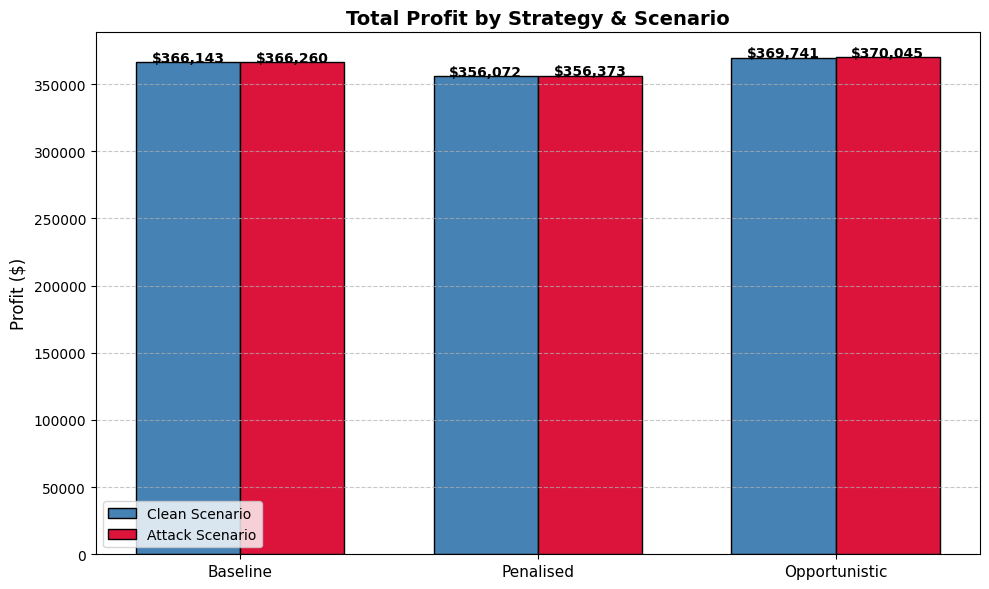

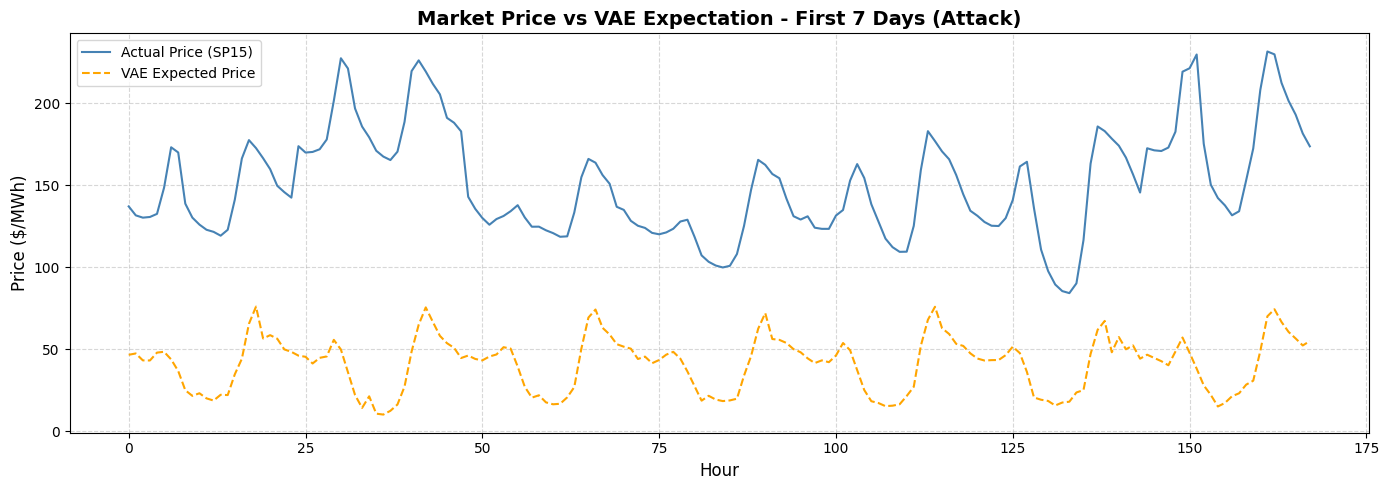

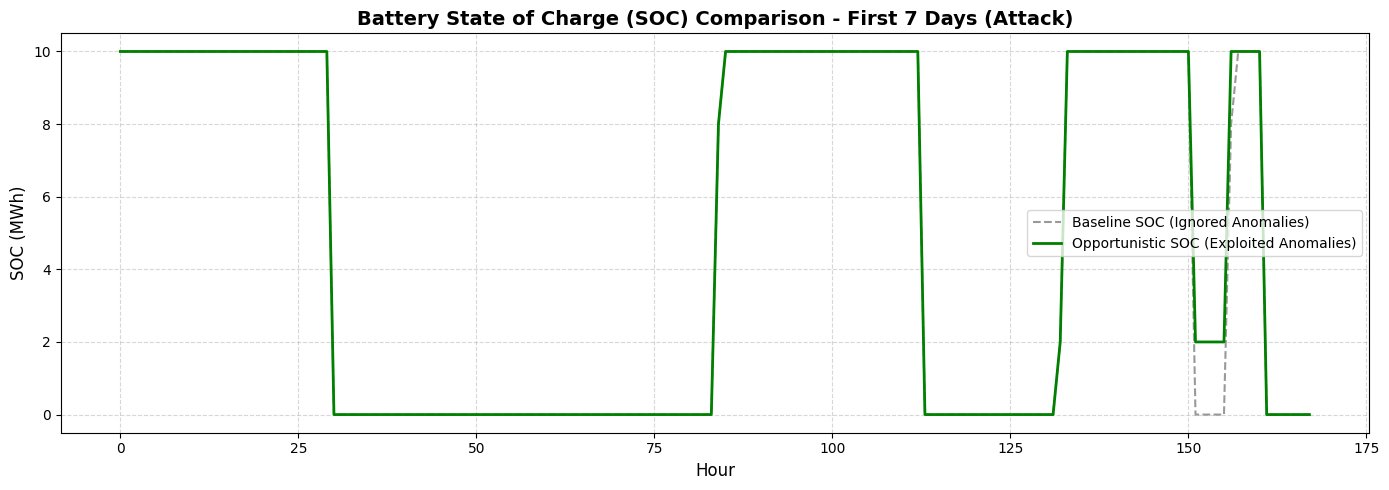

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 🔹 VISUALIZATIONS (Run at the very end)
# ==========================================

def display_results_dashboard():
    print("Generating Interactive Visualizations...")
    
    # ---- 1. Profit Comparison Bar Chart ----
    labels = ['Baseline', 'Penalised', 'Opportunistic']
    clean_profits = [c_base, c_pen, c_opp]
    attack_profits = [a_base, a_pen, a_opp]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width/2, clean_profits, width, label='Clean Scenario', color='steelblue', edgecolor='black')
    ax.bar(x + width/2, attack_profits, width, label='Attack Scenario', color='crimson', edgecolor='black')

    ax.set_ylabel('Profit ($)', fontsize=12)
    ax.set_title('Total Profit by Strategy & Scenario', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add value labels on top of the bars
    for i, v in enumerate(clean_profits):
        ax.text(i - width/2, v + 100, f"${v:,.0f}", ha='center', fontweight='bold')
    for i, v in enumerate(attack_profits):
        ax.text(i + width/2, v + 100, f"${v:,.0f}", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # We will plot the first 7 days (168 hours) to make the charts readable.
    plot_window = 168 

    # ---- 2. VAE Price vs Actual & Anomalies (Attack Scenario) ----
    plt.figure(figsize=(14, 5))
    plt.plot(attack_df['SP15'].values[:plot_window], label='Actual Price (SP15)', color='steelblue')
    plt.plot(attack_df['expected_price'].values[:plot_window], label='VAE Expected Price', color='orange', linestyle='--')

    # Highlight where the model flagged a "Genuine" trending anomaly
    anom_idx = attack_df.index[(attack_df['is_genuine'] == 1) & (attack_df.index < plot_window)].tolist()
    if anom_idx:
        plt.scatter(anom_idx, attack_df['SP15'].iloc[anom_idx], color='red', s=50, label='Detected Anomaly', zorder=5)

    plt.title('Market Price vs VAE Expectation - First 7 Days (Attack)', fontsize=14, fontweight='bold')
    plt.xlabel('Hour', fontsize=12)
    plt.ylabel('Price ($/MWh)', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # ---- 3. Battery Dispatch (SOC) Comparison ----
    plt.figure(figsize=(14, 5))
    
    # Plot Baseline SOC
    plt.plot(a_soc_base[:plot_window], label='Baseline SOC (Ignored Anomalies)', color='gray', linestyle='--', alpha=0.8)
    
    # Plot Opportunistic SOC
    plt.plot(a_soc_opp[:plot_window], label='Opportunistic SOC (Exploited Anomalies)', color='green', linewidth=2)

    plt.title('Battery State of Charge (SOC) Comparison - First 7 Days (Attack)', fontsize=14, fontweight='bold')
    plt.xlabel('Hour', fontsize=12)
    plt.ylabel('SOC (MWh)', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Call the function to display the dashboard
display_results_dashboard()

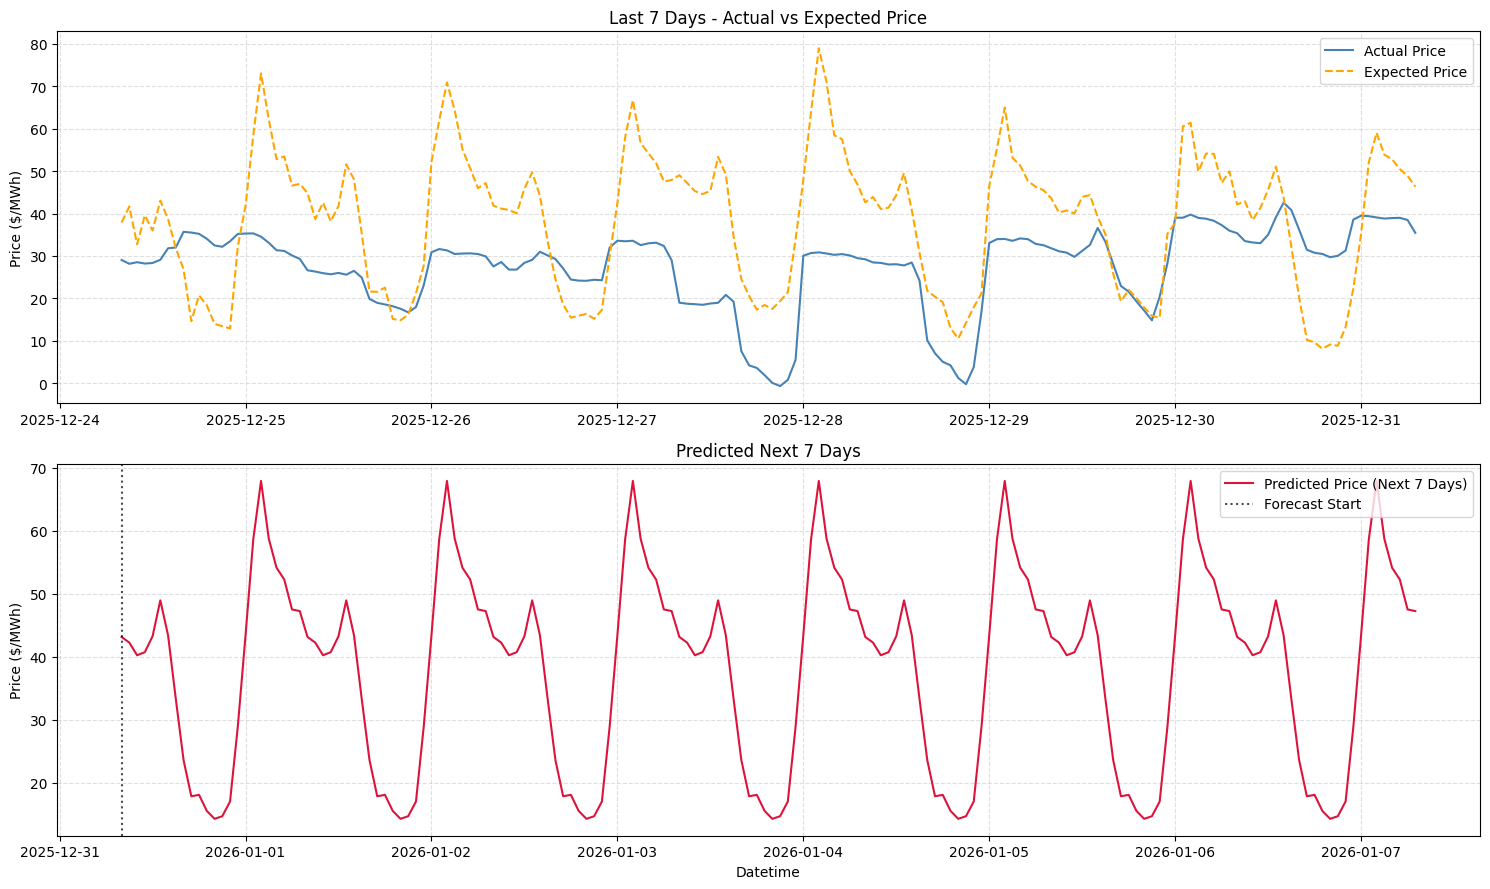

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_last_7_days_and_next_7_days(df, name='attack'):
    df = df.copy()
    df['datetime'] = pd.to_datetime(df['datetime'])

    window_hours = 24 * 7
    history = df.tail(window_hours).reset_index(drop=True)

    if 'expected_price' not in history.columns:
        raise KeyError('expected_price column missing. Run the model pipeline first.')

    # Build a simple 7-day forecast by repeating the average hourly profile of the last 7 days.
    expected_values = history['expected_price'].to_numpy()
    if len(expected_values) >= window_hours:
        hourly_profile = expected_values[:window_hours].reshape(7, 24).mean(axis=0)
    else:
        hourly_profile = np.resize(expected_values[-24:], 24)

    forecast_values = np.tile(hourly_profile, 7)
    future_start = history['datetime'].iloc[-1] + pd.Timedelta(hours=1)
    future_index = pd.date_range(start=future_start, periods=window_hours, freq='h')

    fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=False)

    axes[0].plot(history['datetime'], history['SP15'], label='Actual Price', color='steelblue')
    axes[0].plot(history['datetime'], history['expected_price'], label='Expected Price', color='orange', linestyle='--')
    axes[0].set_title('Last 7 Days - Actual vs Expected Price')
    axes[0].set_ylabel('Price ($/MWh)')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.4)

    axes[1].plot(future_index, forecast_values, label='Predicted Price (Next 7 Days)', color='crimson')
    axes[1].axvline(future_index[0], color='black', linestyle=':', alpha=0.7, label='Forecast Start')
    axes[1].set_title('Predicted Next 7 Days')
    axes[1].set_ylabel('Price ($/MWh)')
    axes[1].set_xlabel('Datetime')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

plot_last_7_days_and_next_7_days(attack_df, name='attack')

<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\l'
C:\Users\KA981\AppData\Local\Temp\ipykernel_34168\370249017.py:45: SyntaxWarning: invalid escape sequence '\l'
  plt.title("Sensitivity Analysis of Anomaly Reactivity ($\lambda$) on Arbitrage Profit", fontsize=14, fontweight='bold')
C:\Users\KA981\AppData\Local\Temp\ipykernel_34168\370249017.py:46: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("Anomaly Sensitivity Parameter ($\lambda$)", fontsize=12)


Starting IEEE Rigorous Sensitivity Sweep...
Solving for sensitivity = 0.0...
Solving for sensitivity = 0.1...
Solving for sensitivity = 0.2...
Solving for sensitivity = 0.3...
Solving for sensitivity = 0.4...
Solving for sensitivity = 0.5...
Solving for sensitivity = 0.6...
Solving for sensitivity = 0.7...
Solving for sensitivity = 0.8...
Solving for sensitivity = 0.9...
Solving for sensitivity = 1.0...
Sweep complete. Generating IEEE-style figure...


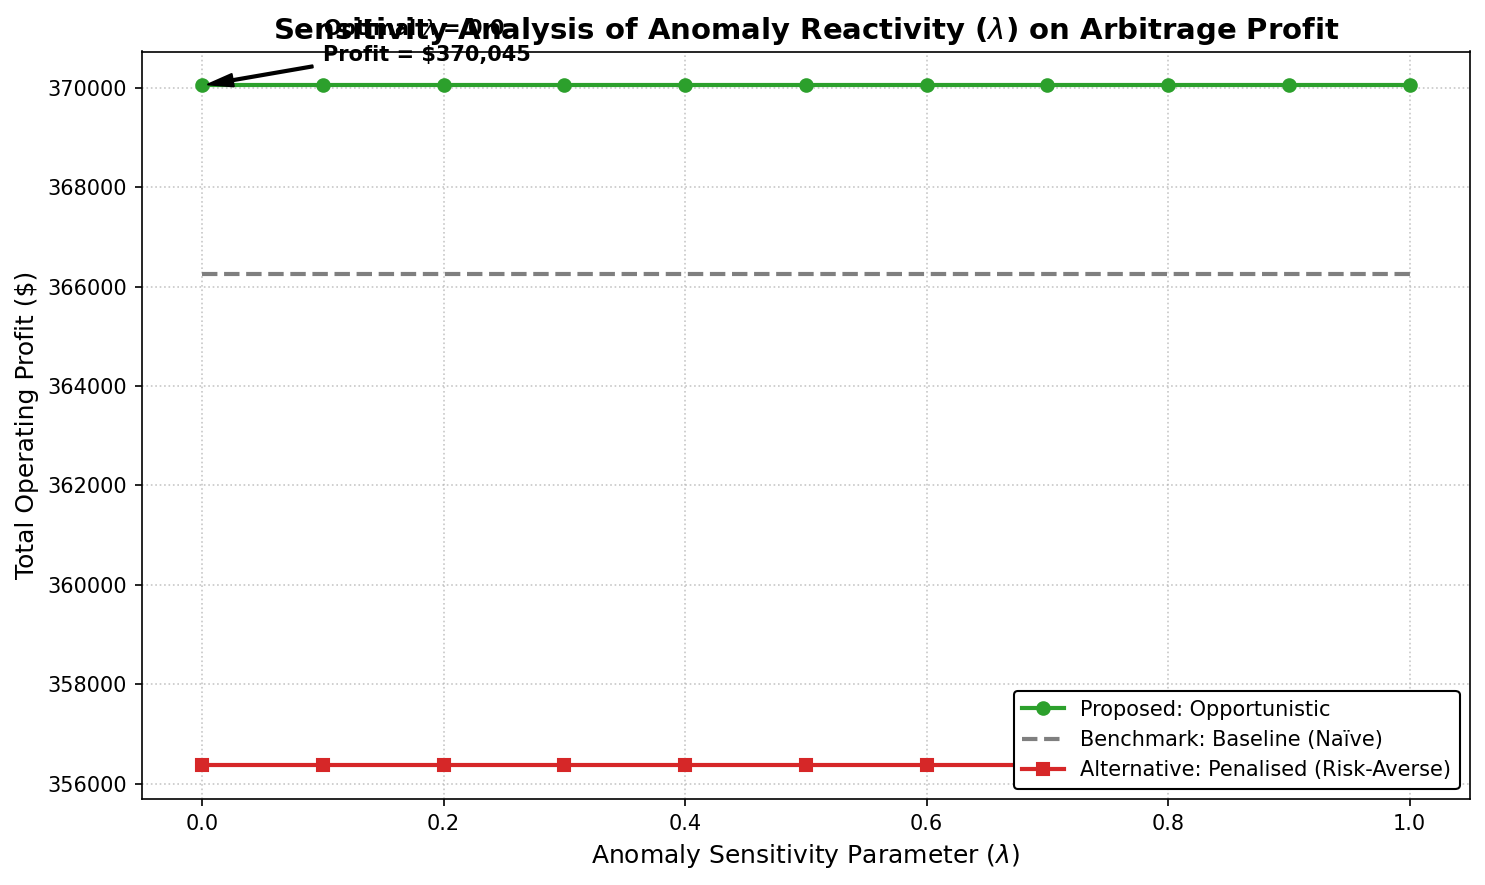

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def run_sensitivity_analysis():
    print("Starting IEEE Rigorous Sensitivity Sweep...")
    
    # Define the range of sensitivities to test (0.0 = ignores anomalies, 1.0 = highly reactive)
    sensitivities = np.linspace(0.0, 1.0, 11) 
    
    # We will test this on the Attack scenario to see how it handles extreme volatility
    opp_profits = []
    pen_profits = []
    
    # Baseline doesn't use sensitivity, so we just run it once
    base_profit, _ = optimize(attack_df, L=100, mode="baseline", anomaly_sensitivity=0)
    baseline_profits = [base_profit] * len(sensitivities)

    for s in sensitivities:
        print(f"Solving for sensitivity = {s:.1f}...")
        p_opp, _ = optimize(attack_df, L=100, mode="opportunistic", anomaly_sensitivity=s)
        p_pen, _ = optimize(attack_df, L=100, mode="penalised", anomaly_sensitivity=s)
        
        opp_profits.append(p_opp)
        pen_profits.append(p_pen)

    print("Sweep complete. Generating IEEE-style figure...")

    # ---- Publication-Ready Plotting ----
    plt.figure(figsize=(10, 6), dpi=150) # High DPI for publication
    
    plt.plot(sensitivities, opp_profits, marker='o', color='#2ca02c', linewidth=2, label='Proposed: Opportunistic')
    plt.plot(sensitivities, baseline_profits, linestyle='--', color='#7f7f7f', linewidth=2, label='Benchmark: Baseline (Naïve)')
    plt.plot(sensitivities, pen_profits, marker='s', color='#d62728', linewidth=2, label='Alternative: Penalised (Risk-Averse)')
    
    # Highlight the optimal point for the Opportunistic strategy
    best_idx = np.argmax(opp_profits)
    best_s = sensitivities[best_idx]
    best_p = opp_profits[best_idx]
    
    plt.annotate(f'Optimal $\\lambda$ = {best_s:.1f}\nProfit = ${best_p:,.0f}', 
                 xy=(best_s, best_p), xytext=(best_s + 0.1, best_p + 500),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
                 fontsize=10, fontweight='bold')

    plt.title("Sensitivity Analysis of Anomaly Reactivity ($\lambda$) on Arbitrage Profit", fontsize=14, fontweight='bold')
    plt.xlabel("Anomaly Sensitivity Parameter ($\lambda$)", fontsize=12)
    plt.ylabel("Total Operating Profit ($)", fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='lower right', framealpha=1.0, edgecolor='black')
    
    plt.tight_layout()
    plt.show()

# Execute the sweep
run_sensitivity_analysis()